# Imports

In [1]:
import pandas as pd
import numpy as np
import os

In [3]:
np.set_printoptions(threshold=1000)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')

# Modèles d'embedding

In [20]:
df = pd.read_csv("data/df_final.csv")

In [21]:
df.head()

,Unnamed: 0,texte,orientation
0,10776,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,gauche
1,10779,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,droite
2,10784,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,gauche
3,10785,RÉPUBLIQUE FRANÇAISE - Liberté - Egalité - Fra...,gauche
4,10790,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,gauche


## TF-IDF

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/opt/python/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/python/lib/python3.13/site-

Meilleurs params: {'svm__C': 3, 'svm__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__sublinear_tf': True}
Meilleur F1 macro (CV sur train): 0.9563198900544971

=== Résultats test (20%) ===
              precision    recall  f1-score   support

      centre      0.963     0.915     0.938       200
      droite      0.947     0.944     0.945       320
      gauche      0.974     0.989     0.981       721

    accuracy                          0.965      1241
   macro avg      0.961     0.949     0.955      1241
weighted avg      0.965     0.965     0.965      1241



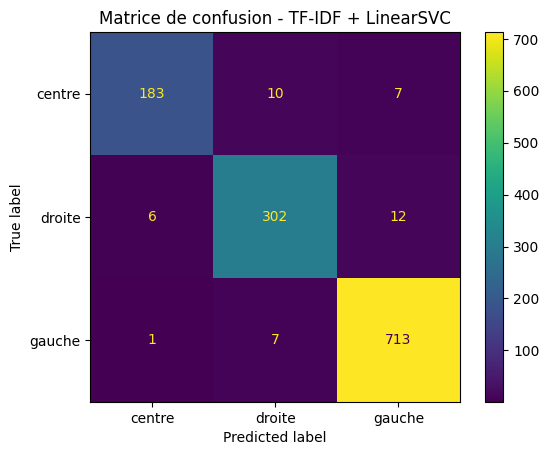


Modèle sauvegardé dans: models/tfidf_linearsvc.joblib


In [ ]:
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
french_stopwords = stopwords.words("french")

import unicodedata
def normalize(text):
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8").lower()
stopwords_clean = [normalize(w) for w in french_stopwords]

# paramètres colonnes
TEXT_COL = "texte"
Y_COL = "orientation"

# nettoyage minimal
df_tfidf = df.copy()
X = df_tfidf[TEXT_COL].astype(str)
y = df_tfidf[Y_COL].astype(str)

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# pipeline
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    stop_words=stopwords_clean,)),
    ("svm", LinearSVC())
])

# grille
param_grid = {
    # TF-IDF
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__norm": ["l2", None],
    # SVM
    "svm__C": [0.1, 0.3, 1, 3, 10],
    "svm__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gridsearch sur TRAIN uniquement
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

print("Meilleurs params:", gs.best_params_)
print("Meilleur F1 macro (CV sur train):", gs.best_score_)

# entrainer le meilleur modèle sur tout le train
best_model = gs.best_estimator_
best_model.fit(X_train, y_train)

# test sur les autres 20%
y_pred = best_model.predict(X_test)

print("\n=== Résultats test (20%) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(values_format="d")
plt.title("Matrice de confusion - TF-IDF + LinearSVC")
plt.show()

# sauvegarde
joblib.dump(best_model, "models/tfidf_linearsvc.joblib")
print("\nModèle sauvegardé dans: models/tfidf_linearsvc.joblib")

In [ ]:
tfidf_svm = joblib.load("models/tfidf_linearsvc.joblib")

## Doc2Vec

In [23]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 72.6 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]2m1/2 [gensim]


Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=3; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=3; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=0.1; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=1; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=3; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=0.1; total time= 3.5min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, svm__C=1; total time= 3.4min
[CV] END d2v__dm=0, d2v__infer_steps=30, d2v__min_count=2, d2v__negative=5, d2v__window=5, sv

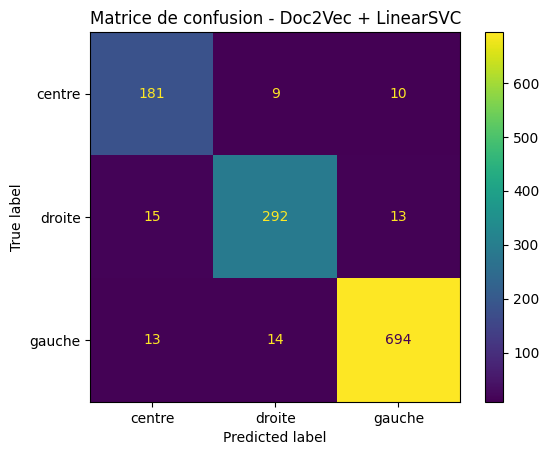


Modèle sauvegardé dans: models/d2v_linearsvc.joblib


In [ ]:
import re
import numpy as np
import joblib

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Tokenizer
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


# Doc2Vec
class Doc2VecVectorizer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        vector_size=300,
        window=8,
        min_count=2,
        epochs=30,
        dm=1,
        negative=10,
        sample=1e-5,
        hs=0,
        workers=4,
        seed=42,
        infer_steps=50,
        infer_alpha=0.025):

        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.dm = dm
        self.negative = negative
        self.sample = sample
        self.hs = hs
        self.workers = workers
        self.seed = seed
        self.infer_steps = infer_steps
        self.infer_alpha = infer_alpha
        self.model_ = None

    def fit(self, X, y=None):
        X = list(X)

        tagged = [
            TaggedDocument(words=simple_tokenize(text), tags=[str(i)])
            for i, text in enumerate(X)
        ]

        self.model_ = Doc2Vec(
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            epochs=self.epochs,
            dm=self.dm,
            negative=self.negative,
            sample=self.sample,
            hs=self.hs,
            seed=self.seed)

        self.model_.build_vocab(tagged)
        self.model_.train(tagged, total_examples=self.model_.corpus_count, epochs=self.model_.epochs)
        return self

    def transform(self, X):
        X = list(X)
        # On infère un vecteur pour chaque document (valable aussi pour train/test/folds)
        return np.vstack([
            self.model_.infer_vector(
                simple_tokenize(text),
                alpha=self.infer_alpha,
                epochs=self.infer_steps)
            for text in X
        ])


# Données
TEXT_COL = "texte"
Y_COL = "orientation"

df_d2v = df.dropna(subset=[TEXT_COL, Y_COL]).copy()
X = df_d2v[TEXT_COL].astype(str).values
y = df_d2v[Y_COL].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)


# Pipeline + GridSearchCV
pipe = Pipeline([
    ("d2v", Doc2VecVectorizer(vector_size=200,epochs=30,seed=42)),
    ("svm", LinearSVC(class_weight="balanced", max_iter=10000))
])

param_grid = {
    # Doc2Vec
    "d2v__dm": [0, 1],
    "d2v__window": [5, 8],
    "d2v__min_count": [2, 5],
    "d2v__negative": [5, 10],
    "d2v__infer_steps": [30, 80],
    # SVM
    "svm__C": [0.1, 1, 3, 10]}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2)

grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres:\n", grid.best_params_)
print("Meilleur score CV (f1_macro):", grid.best_score_)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)


# Évaluation sur le test
y_pred = best_model.predict(X_test)
print("\n=== Résultats test (20%) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(values_format="d")
plt.title("Matrice de confusion - Doc2Vec + LinearSVC")
plt.show()

# sauvegarde
joblib.dump(best_model, "models/d2v_linearsvc.joblib")
print("\nModèle sauvegardé dans: models/d2v_linearsvc.joblib")

In [ ]:
d2v_svm = joblib.load("models/d2v_linearsvc.joblib")

## SBERT (affiner la grille de la CV)

In [ ]:
!pip install matplotlib
!pip install spacy
!python -m spacy download fr_core_news_sm
!pip install -U sentence-transformers

In [22]:
import spacy
nlp = spacy.load("fr_core_news_sm")
df["nb_tokens"] = df["texte"].apply(lambda x: len(nlp(x)))

In [23]:
nb_textes_long = (df["nb_tokens"] > 512).sum()
print("Nombre de textes avec plus de 512 tokens :", nb_textes_long)

Nombre de textes avec plus de 512 tokens : 4832


In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["nb_tokens"], bins=50)
plt.title("Distribution du nombre de tokens")
plt.xlabel("Nombre de tokens")
plt.ylabel("Nombre de textes")
plt.show()

Fitting 5 folds for each of 6 candidates, totalling 30 fits


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6526.39it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (729 > 128). Running this sequence through the model will result in indexing errors


[CV] END .............embed__agg_method=mean_max, svm__C=0.1; total time= 4.7min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4951.34it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (1942 > 128). Running this sequence through the model will result in indexing errors


[CV] END .............embed__agg_method=mean_max, svm__C=0.1; total time= 4.6min


...

[CV] END ........embed__agg_method=weighted_mean, svm__C=1.0; total time= 5.4min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4633.54it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (1942 > 128). Running this sequence through the model will result in indexing errors


[CV] END ........embed__agg_method=weighted_mean, svm__C=1.0; total time= 5.4min


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3315.88it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (1942 > 128). Running this sequence through the model will result in indexing errors


Meilleurs hyperparamétres:
 {'embed__agg_method': 'weighted_mean', 'svm__C': 1.0}
Meilleur score CV (f1_macro): 0.8249892078665141

=== Résultats tests (20%) ===
              precision    recall  f1-score   support

      centre       0.76      0.80      0.78       200
      droite       0.84      0.82      0.83       320
      gauche       0.94      0.94      0.94       721

    accuracy                           0.89      1241
   macro avg       0.85      0.85      0.85      1241
weighted avg       0.89      0.89      0.89      1241



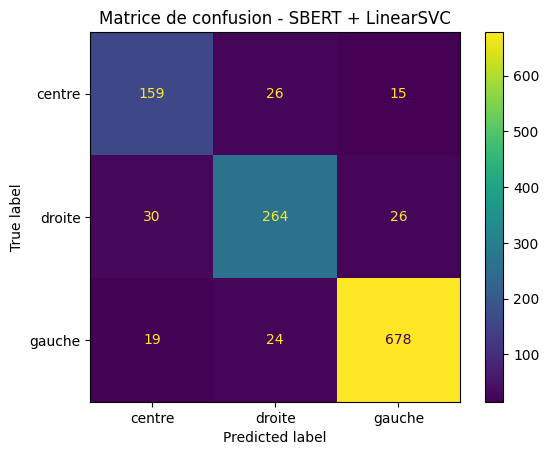


Modèle sauvegardé dans: models/sbert_linearsvc.joblib


In [ ]:
import numpy as np
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt


import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sentence_transformers import SentenceTransformer


class SBERTChunkEmbedder(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        max_seq_length=512,
        stride=64,
        agg_method="mean",
        normalize_embeddings=True,
        batch_size=32,
        show_progress_bar=False,
        device="cuda",
        random_state=42
    ):
        self.model_name = model_name
        self.max_seq_length = max_seq_length
        self.stride = stride
        self.agg_method = agg_method
        self.normalize_embeddings = normalize_embeddings
        self.batch_size = batch_size
        self.show_progress_bar = show_progress_bar
        self.device = device
        self.random_state = random_state

        self._model = None
        self._tokenizer = None
        self._dim = None
        self._loaded_model_name = None

    def _load_model(self):
        if self._model is None or self._loaded_model_name != self.model_name:
            self._model = SentenceTransformer(self.model_name, device=self.device)
            self._tokenizer = self._model.tokenizer
            self._dim = self._model.get_sentence_embedding_dimension()
            self._loaded_model_name = self.model_name

        self._model.max_seq_length = int(self.max_seq_length)

    def fit(self, X, y=None):
        self._load_model()
        return self

    def _chunk_text_by_tokens(self, text: str):
        if not isinstance(text, str) or not text.strip():
            return []

        max_body = max(1, int(self.max_seq_length) - 2)

        enc = self._tokenizer(
            text,
            add_special_tokens=False,
            truncation=False,
            return_attention_mask=False,
            return_tensors=None
        )
        ids = enc["input_ids"]
        if len(ids) <= max_body:
            return [text]

        stride = int(self.stride)
        if stride < 0:
            stride = 0
        if stride >= max_body:
            stride = max_body // 2

        chunks = []
        start = 0
        n = len(ids)

        while start < n:
            end = min(start + max_body, n)
            chunk_ids = ids[start:end]
            chunk_text = self._tokenizer.decode(chunk_ids, skip_special_tokens=True)
            if chunk_text.strip():
                chunks.append(chunk_text)
            if end == n:
                break
            start = max(0, end - stride)

        return chunks

    @staticmethod
    def _aggregate(embs: np.ndarray, method: str, weights: np.ndarray | None = None):
        if method == "mean":
            return embs.mean(axis=0)
        if method == "max":
            return embs.max(axis=0)
        if method == "mean_max":
            return np.concatenate([embs.mean(axis=0), embs.max(axis=0)], axis=0)
        if method == "weighted_mean":
            if weights is None:
                raise ValueError("weights requis pour weighted_mean")
            w = weights / (weights.sum() + 1e-12)
            return (embs * w[:, None]).sum(axis=0)
        raise ValueError(f"Unknown agg_method={method}")

    def transform(self, X):
        self._load_model()  # réapplique max_seq_length à chaque transform

        texts = list(X)
        doc_embs = []

        for text in texts:
            chunks = self._chunk_text_by_tokens(text)
            if len(chunks) == 0:
                doc_embs.append(np.zeros(self._dim, dtype=np.float32))
                continue

            chunk_embs = self._model.encode(
                chunks,
                batch_size=self.batch_size,
                show_progress_bar=self.show_progress_bar,
                convert_to_numpy=True,
                normalize_embeddings=bool(self.normalize_embeddings),
            )

            if self.agg_method == "weighted_mean":
                weights = np.array(
                    [len(self._tokenizer(c, add_special_tokens=False)["input_ids"]) for c in chunks],
                    dtype=np.float32
                )
                doc_vec = self._aggregate(chunk_embs, self.agg_method, weights=weights)
            else:
                doc_vec = self._aggregate(chunk_embs, self.agg_method)

            doc_embs.append(doc_vec.astype(np.float32))

        return np.vstack(doc_embs)


# Préparer données
TEXT_COL = "texte"
Y_COL = "orientation"

df_sbert = df.copy()
X = df_sbert[TEXT_COL].astype(str).tolist()
y = df_sbert[Y_COL].astype(str).tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)


# Pipeline + GridSearchCV
pipe = Pipeline([
    ("embed", SBERTChunkEmbedder(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", normalize_embeddings=True, device="cuda", max_seq_length=256, stride=32)),
    ("svm", LinearSVC(class_weight="balanced"))])

param_grid = {
    # SBERT
    "embed__agg_method": ["mean_max", "weighted_mean"], # "mean", "max",
    # SVM
    "svm__C": [0.1, 0.5, 1.0]} #  2.0, 5.0

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2)

gs.fit(X_train, y_train)

print("Meilleurs hyperparamétres:\n", gs.best_params_)
print("Meilleur score CV (f1_macro):", gs.best_score_)

best_model = gs.best_estimator_
best_model.fit(X_train, y_train)


# Évaluation sur le test
y_pred = best_model.predict(X_test)
print("\n=== Résultats tests (20%) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(values_format="d")
plt.title("Matrice de confusion - SBERT + LinearSVC")
plt.show()

# sauvegarde
joblib.dump(best_model, "models/sbert_linearsvc.joblib")
print("\nModèle sauvegardé dans: models/sbert_linearsvc.joblib")

In [ ]:
sbert_svm = joblib.load("models/sbert_linearsvc.joblib")